# K-means clustering

## By the end of this notebook, you'll be able to:
- Generate some random data
- Run a k-means clustering algorithm
- Time your code

### Load all the packages that will be required for the notebook.

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Feb  2 14:54:04 2026

@author: av
"""

# The usual suspects - import numpy and matplotlib
...

# Packages needed for generating data, and for K-means clustering
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from matplotlib.animation import FuncAnimation

### Setup some parameters and generate some random data

In [ ]:
# Set seed for the random number generator - this is for reproducibility
rng_seed=42
np.random.seed(rng_seed)

# Generate some sample data
n_samples = 100
n_components = 3

X, y_true = make_blobs(n_samples=n_samples, centers=n_components, cluster_std=0.6, random_state=0)

## Step 0 - Know (visualize) your data

Ellipsis

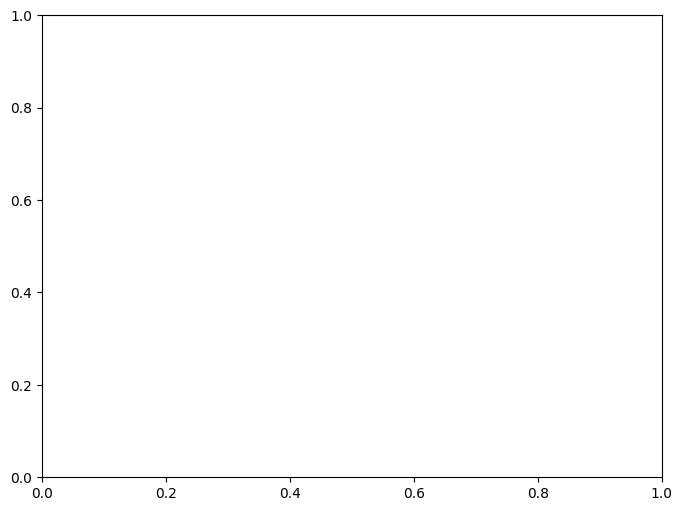

In [ ]:
# Can you add code here to plot the data?
# Hint: The data is in the "X" variable, with x and y coords in the first and second columns, respectively

fig, ax = plt.subplots(figsize=(8,6))
...

## Apply K-means clustering algorithm

This is an extremely simple step when using the KMeans function from sklearn.

In [ ]:
# Perform K-means clustering
kmeans = KMeans(
    n_clusters=n_components,
    random_state=0,
    max_iter=100).fit(X)

Ellipsis

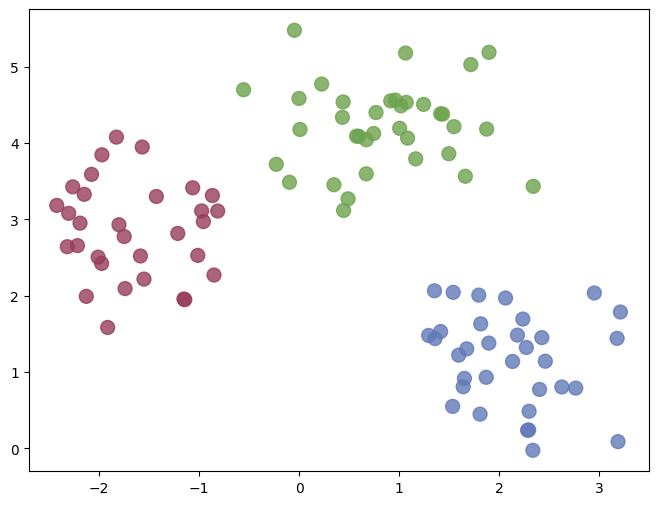

In [ ]:
# Plot the output
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(X[:,0], X[:,1], color=colors[kmeans.labels_], s=100, alpha=0.8)

# Can you overlay the cluster centroids on this plot?
# Hint: They are stored in the 'kmeans' object, as the parameter "cluster_centers_".

...

## How long does K-means take to run on this data?

In [ ]:
import timeit # This is used for timing your code

# Start the timer
start_time = timeit.default_timer()

# Run your code (i.e. perform the clustering)
...

# End the timer
end_time = timeit.default_timer()

# Calculate and print the elapsed time
print(f"The k-means clustering took {1000*(end_time - start_time): .3f} milliseconds")

The k-means clustering took  6.691 milliseconds


## Animation of k-means clustering

### Below is some code to produce an animation of the k-means clustering analysis, running through each iteration step-by-step. Use this to explore how the algorithm works, and build your intuition of this method.

In [ ]:
# Perform the k-means clustering
n_iterations = 15

colors = ["#963d5a", "#6279b8", "#6DA34D", "#496f5d", "#e7bb41"]
colors = np.array(colors)

centroid_color = "#0c120c"

fig, ax = plt.subplots(figsize=(8,6))

# Change seed - this will give you different initial centroids
new_seed = rng_seed*10
np.random.seed(new_seed)

# Define the update function to update the frame
current_centroids = np.random.randn(n_components, 2)
def update(frame):
    global current_centroids
    ax.clear()

    if frame < 2:
        ax.scatter(X[:,0], X[:,1], color='k', s=120, alpha=0.75)
    else:
        # Perform 1 step of K-means clustering
        kmeans = KMeans(
            n_clusters=n_components,
            random_state=0,
            max_iter=1,
            init=current_centroids,
            n_init=1).fit(X)
        # Update centroid for each iteration
        current_centroids = kmeans.cluster_centers_

        ax.scatter(X[:,0], X[:,1], color=colors[kmeans.labels_], s=120, alpha=0.75)
        ax.scatter(current_centroids[:,0], current_centroids[:,1],
                   c=centroid_color, marker='X', s=200)
        ax.set_title(f'Iteration {frame-1}')

# Define animation object
animation = FuncAnimation(fig, update, frames=n_iterations+2, repeat=False)

# Close the figure to prevent it from displaying as a static plot
plt.close(fig)

# Display the animation interactively in the notebook
from IPython.display import HTML, display
display(HTML(animation.to_jshtml()))

## Learn more about the KMeans function and its parameters here:
## https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

### How do we choose _k_?

#### One option is the "Elbow" method.
#### Here, you run the KMeans algorithm multiple times, once for each different value of _k_.
#### Then you calculate a "dissimilarity metric" [inertia] across the data, and find the "elbow" in this.

In [ ]:
# Run k-means clustering with different values of k
ks = np.arange(1, 11)
dissimilarities = np.zeros(ks.shape[0])

for i, k in enumerate(ks):
  # Run k-means clustering
  clustering = KMeans(...).fit(X)
  # Store the dissimilarity index (stored in the "inertia_" property)
  dissimilarities[i] =  ...

Text(0.5, 1.0, 'Elbow Method')

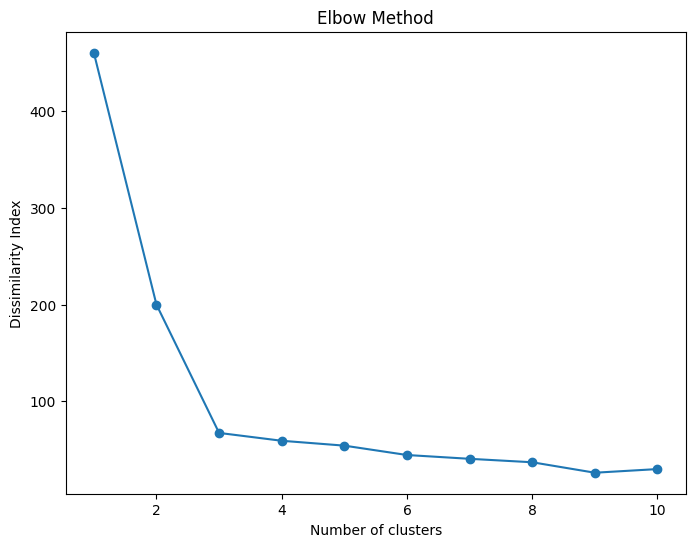

In [ ]:
# Plot dissimilarities
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ks, dissimilarities, marker='o')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Dissimilarity Index')
ax.set_title('Elbow Method')